In [99]:
import torch
import torch.nn as nn
import torch.nn.functional as F
import torchvision
from torch.utils.data import DataLoader, Subset
from torchvision import transforms, datasets, models
import numpy as np
import matplotlib.pyplot as plt

In [100]:
device = 'cuda' if torch.cuda.is_available() else 'cpu'

In [101]:
#Predefined varibales

BATCH_SIZE = 12
IMG_SIZE =28
PATCH_SIZE = 7
ATTENTION_HEADS = 4
TRANSFOMER_LAYERS = 4
EMBED_DIM = 32
CLASSES = 10
EPOCHS_STUDENT = 10
LR_STUDENT = 1e-4
CHANNELS = 3
TEMPERATURE = 2
ALPHA = 0.5

In [102]:
#import data

data_transformations=transforms.Compose([
    transforms.ToTensor(),
    transforms.Lambda(lambda t: t.repeat(3,1,1))
])

train_full = datasets.MNIST('./data',train=True,download=True,transform=data_transformations)
val_ds =datasets.MNIST('./data',train=False,download=True,transform=data_transformations)

#splitting data
n=int(1*len(train_full))
subset_idx=np.random.permutation(len(train_full))[:n]

train_ds=Subset(train_full, subset_idx)

In [103]:
#create train and validation datat loaders

train_dl=DataLoader(train_ds,batch_size=BATCH_SIZE,shuffle=True)
val_dl=DataLoader(val_ds,batch_size=BATCH_SIZE)

In [104]:
#Teacher model

teacher = models.resnet50( weights= models.ResNet50_Weights.IMAGENET1K_V2)

#imagenet last layer is 1000 because of 1000 classes
#but our dataset has only 10 classes so change last fully connected layer output features to 10(CLASSES)

teacher.fc=nn.Linear(teacher.fc.in_features,CLASSES)
teacher.to(device)

for parameter in teacher.parameters():
  parameter.requires_grad=False

for parameter in teacher.fc.parameters():
  parameter.requires_grad=True

In [105]:
#Student model - ViT


#create patches from images using 2d convolution
class PatchEmbed(nn.Module):

  def __init__(self,channels=CHANNELS,embed_dim=EMBED_DIM,patch_size=PATCH_SIZE,img_size=IMG_SIZE):
    super().__init__()
    self.proj = nn.Conv2d(channels,embed_dim,patch_size,patch_size)#kernel size and stride are same(patch size) to get overlapping patches
    self.n= (img_size//patch_size)**2 # no of patches in a image


  def forward(self,x):
    x=self.proj(x)
    #flattening the patches
    x=x.flatten(2)
    #swapping embed_dim to last
    x=x.transpose(1,2)
    return x



In [106]:
#Student Vit class

class Vit(nn.Module):

    def __init__(self, embed_dim=EMBED_DIM, attention_heads=ATTENTION_HEADS, layers=TRANSFOMER_LAYERS, classes=CLASSES):
        super().__init__()
        self.patch_embed = PatchEmbed()
        #cls token
        self.cls = nn.Parameter(torch.zeros(1,1,embed_dim))#(1,1,dim)-(batch_size,patch_size,embed_dim)
        #distillation token
        self.distillation = nn.Parameter(torch.zeros(1,1,embed_dim))#(1,1,dim)-(batch_size,patch_size,embed_dim)
        #positional embedding
        self.n = self.patch_embed.n
        self.position_embed = nn.Parameter(torch.zeros(1,self.n+2,embed_dim)) #n+2 because no of patches + cls token + distillation tokrn
        # transformers
        qkv_dim = embed_dim//attention_heads
        self.transformer_blocks = nn.Sequential(*[nn.TransformerEncoderLayer(embed_dim, attention_heads, qkv_dim, batch_first=True) for _ in range(layers)])

        self.layernorm = nn.LayerNorm(embed_dim)
        #classification head
        self.head_cls = nn.Linear(embed_dim, classes)
        self.head_distill = nn.Linear(embed_dim, classes)

    def forward(self, x):
        B = x.shape[0]
        x = self.patch_embed(x)
        #expanding cls tokens for all inputs in a batch
        cls = self.cls.expand(B, -1, -1)
        dist = self.distillation.expand(B, -1, -1)

        #appending cls token and prepending distillation token
        x = torch.cat([cls, x, dist], 1) + self.position_embed #here brodacsting expands positional embeddings according to x's dimension

        x = self.transformer_blocks(x)
        x = self.layernorm(x)

        #1st embedding in context vector
        cls_token = x[:,0]

        #last embedding in context vector
        distil_token = x[:,-1]

        cls_logits = self.head_cls(cls_token)
        distil_logits = self.head_distill(distil_token)

        return cls_logits, distil_logits

In [107]:
#define student model

student = Vit().to(device)
opt_s = torch.optim.AdamW(student.parameters(),lr = LR_STUDENT)

In [108]:
# define the loss function

def kd_loss(cls_logits,distill_logits,teacher_logits,y,alpha=ALPHA, temperature= TEMPERATURE):
  # y - gorund truth (original values)
  # student_logits - prediction logits from student models(cls and distill logits)
  # teacher_logits - prediction logits from teacher model - resnet50

  #KL Divergence - calculated between distill logits and teacher logits
  kd = F.kl_div(F.softmax(distill_logits/temperature,dim=-1),
                F.softmax(teacher_logits/temperature,dim=-1),
                reduction='batchmean'
                ) * (temperature*temperature)
  #cross entropy loss from student logit(cls logit) and gorund truth(true value labels)
  ce=F.cross_entropy(cls_logits,y)

  return alpha*kd + (1-alpha)*ce

In [109]:
# running epochs

for e in range(EPOCHS_STUDENT):
  student.train()
  for x, y in train_dl: # x- input data, y-true value for that data
    x,y=x.to(device),y.to(device)

    # teacher prediction without gradient calculation and tracking
    with torch.no_grad():
      teacher_logits=teacher(x)

    #student predictions
    cls_logits,distill_logits=student(x)

    #calculating loss
    loss=kd_loss(cls_logits,distill_logits,teacher_logits,y)

    opt_s.zero_grad()
    #backward pass
    loss.backward()

    # optimizer changing model weights according to loss
    opt_s.step()
  print(f"Epoch {e+1} done")

Epoch 1 done
Epoch 2 done
Epoch 3 done
Epoch 4 done
Epoch 5 done
Epoch 6 done
Epoch 7 done
Epoch 8 done
Epoch 9 done
Epoch 10 done


In [119]:
#validation

student.eval()

correct=0
total=0

samples=[]

with torch.no_grad():
  for x,y in val_dl:
    x,y=x.to(device), y.to(device)
    cls_logits,distill_logits=student(x)
    cls_dist=(cls_logits+distill_logits)/2
    #getting predicted values from predicts logits of distillation token which is influenced by teacher model during training
    pred=cls_logits.argmax(1)

    correct+=(pred==y).sum().item()
    total+=y.size(0)

    if len(samples)<10:
      samples.append((x.cpu(),pred.cpu(),y.cpu()))

acc=100*correct/total
print(f"Test Accuracy: {acc:.2f}%")

Test Accuracy: 96.07%


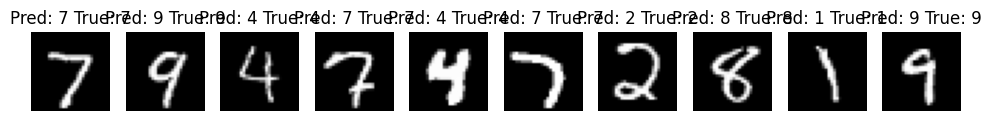

In [122]:
#display predictions

fig,axs=plt.subplots(1,len(samples),figsize=(12,3))

for i ,(img,pred,true) in enumerate(samples):
  img=(img[0].permute(1,2,0).numpy())
  axs[i].imshow(img)
  axs[i].set_title(f"Pred: {pred[0].item()} True: {true[0].item()}")
  axs[i].axis('off')
plt.show()